In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
alpha=0
fref=25
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                      fref=fref,alpha=alpha)

/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:106: RuntimeWarning: divide by zero encountered in power
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:115: ComplexWarning: Casting complex values to real discards the imaginary part


stochastic: Done with Interval 1 / 95
	Y     = -2.896472e-09
	sigma = 1.171284e-08
	SNR   = -0.247290
stochastic: Done with Interval 2 / 95
	Y     = -3.098482e-09
	sigma = 1.096071e-08
	SNR   = -0.282690
stochastic: Done with Interval 3 / 95
	Y     = -1.785092e-08
	sigma = 1.151991e-08
	SNR   = -1.549572
stochastic: Done with Interval 4 / 95
	Y     = 1.475431e-08
	sigma = 1.184256e-08
	SNR   = 1.245872
stochastic: Done with Interval 5 / 95
	Y     = 7.226091e-09
	sigma = 1.054662e-08
	SNR   = 0.685157
stochastic: Done with Interval 6 / 95
	Y     = -3.057391e-09
	sigma = 9.979661e-09
	SNR   = -0.306362
stochastic: Done with Interval 7 / 95
	Y     = -1.470872e-08
	sigma = 1.120645e-08
	SNR   = -1.312524
stochastic: Done with Interval 8 / 95
	Y     = 2.468041e-08
	sigma = 1.158670e-08
	SNR   = 2.130064
stochastic: Done with Interval 9 / 95
	Y     = 6.213566e-09
	sigma = 1.048653e-08
	SNR   = 0.592528
stochastic: Done with Interval 10 / 95
	Y     = 5.706828e-09
	sigma = 9.920385e-09
	SNR   

stochastic: Done with Interval 85 / 95
	Y     = 1.346679e-08
	sigma = 1.152818e-08
	SNR   = 1.168163
stochastic: Done with Interval 86 / 95
	Y     = 1.187866e-09
	sigma = 1.078327e-08
	SNR   = 0.110158
stochastic: Done with Interval 87 / 95
	Y     = 2.493963e-09
	sigma = 1.057372e-08
	SNR   = 0.235864
stochastic: Done with Interval 88 / 95
	Y     = -5.289008e-11
	sigma = 1.151657e-08
	SNR   = -0.004593
stochastic: Done with Interval 89 / 95
	Y     = 2.232616e-08
	sigma = 1.161219e-08
	SNR   = 1.922649
stochastic: Done with Interval 90 / 95
	Y     = 1.938033e-08
	sigma = 1.185592e-08
	SNR   = 1.634655
stochastic: Done with Interval 91 / 95
	Y     = -4.224091e-09
	sigma = 1.099283e-08
	SNR   = -0.384259
stochastic: Done with Interval 92 / 95
	Y     = 9.749524e-09
	sigma = 1.036194e-08
	SNR   = 0.940898
stochastic: Done with Interval 93 / 95
	Y     = -1.683686e-08
	sigma = 1.079217e-08
	SNR   = -1.560099
stochastic: Done with Interval 94 / 95
	Y     = 7.716727e-09
	sigma = 1.249745e-08
	S

In [6]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in true_divide
  from ipykernel import kernelapp as app
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in true_divide
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: divide by zero encountered in true_divide
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:28: RuntimeWarning: invalid value encountered in subtract
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in subtract
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in subtract


00:46 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
00:46 bilby INFO    : Search parameters:
00:46 bilby INFO    :   A = Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
00:46 bilby INFO    :   alpha = Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
00:46 bilby INFO    : Single likelihood evaluation took 1.788e-04 s


0it [00:00, ?it/s]

00:46 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 500, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 300, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fc6f43c7110>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
00:46 bilby INFO    : Checkpoint every n_check_point = 3000000
00:46 bilby INFO    : Using dynesty version 1.0.1
00:46 bilby INFO    : Using the bilby-implemented rwalk samp

4505it [00:47, 62.56it/s, bound:419 nc:50 ncall:149873 eff:3.0% logz-ratio=173.35+/-nan dlogz:0.101>0.10]    

00:47 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



4511it [00:48, 93.58it/s, bound:420 nc:1 ncall:150181 eff:3.3% logz-ratio=173.44+/-nan dlogz:0.000>0.10] 



00:47 bilby INFO    : Sampling time: 0:00:46.975921
00:47 bilby INFO    : Summary of results:
nsamples: 5011
log_noise_evidence: -1934.316
log_evidence: -1760.873 +/-    nan
log_bayes_factor: 173.443 +/-    nan



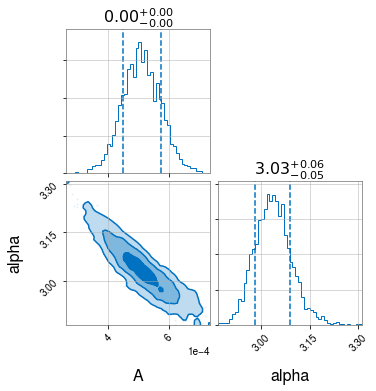

In [7]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],var_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [8]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

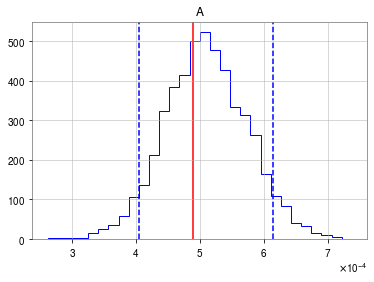

In [9]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red')

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

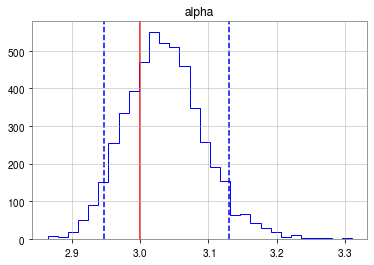

In [10]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')

00:47 bilby INFO    : Running for label 'GWB_brokenpowerlaw', output will be saved to 'outdir'
00:47 bilby INFO    : Search parameters:
00:47 bilby INFO    :   A = Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
00:47 bilby INFO    :   alpha1 = Uniform(minimum=-5, maximum=5, name='alpha1', latex_label='alpha1', unit=None, boundary=None)
00:47 bilby INFO    :   alpha2 = Uniform(minimum=-5, maximum=5, name='alpha2', latex_label='alpha2', unit=None, boundary=None)
00:47 bilby INFO    :   fbreak = Uniform(minimum=30, maximum=100, name='fbreak', latex_label='fbreak', unit=None, boundary=None)
00:47 bilby INFO    : Single likelihood evaluation took 2.687e-04 s


0it [00:00, ?it/s]

00:47 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 500, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 300, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fc6deee1ed0>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
00:47 bilby INFO    : Checkpoint every n_check_point = 2000000
00:47 bilby INFO    : Using dynesty version 1.0.1
00:47 bilby INFO    : Using the bilby-implemented rwalk samp

6317it [02:27, 40.23it/s, bound:549 nc:19 ncall:193519 eff:3.3% logz-ratio=170.63+/-nan dlogz:0.101>0.10]    

00:49 bilby INFO    : Writing checkpoint file outdir/GWB_brokenpowerlaw_resume.pickle



6321it [02:29, 42.37it/s, bound:549 nc:1 ncall:193660 eff:3.5% logz-ratio=170.71+/-nan dlogz:0.000>0.10] 



00:49 bilby INFO    : Sampling time: 0:02:27.560327
00:49 bilby INFO    : Summary of results:
nsamples: 6821
log_noise_evidence: -1934.316
log_evidence: -1763.607 +/- 2043524.746
log_bayes_factor: 170.709 +/- 2043524.746



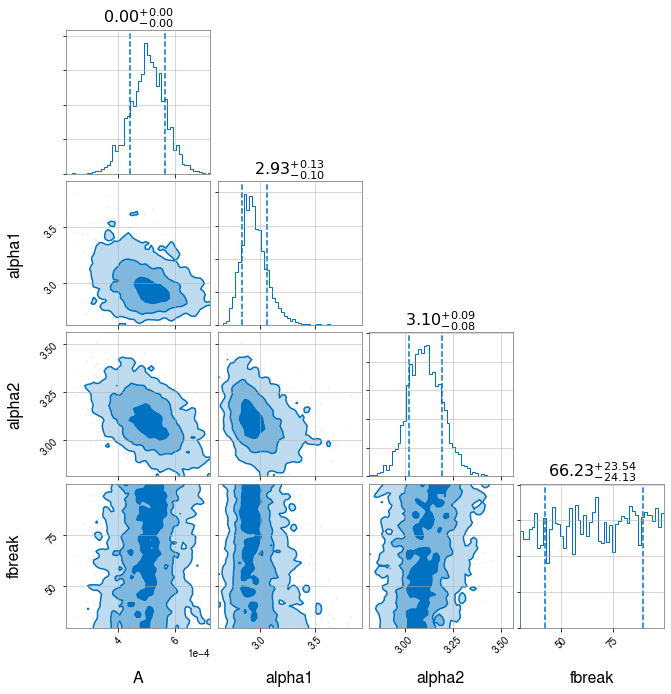

In [11]:
# A few simple setup steps
label = 'GWB_brokenpowerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax = 1e-10,1e-3
alpha1_min,alpha1_max=-5,5
alpha2_min,alpha2_max=-5,5
fbreak_min,fbreak_max=30,100
    

fref=25

baselines=[Baseline('test',Y_f[1:],var_f[1:],freqs[1:])]

likelihood = BrokenPowerLawGWBLikelihood(baselines,fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha1=bilby.core.prior.Uniform(alpha1_min,alpha1_max, 'alpha1'),
              alpha2=bilby.core.prior.Uniform(alpha2_min,alpha2_max, 'alpha2'),
              fbreak=bilby.core.prior.Uniform(fbreak_min,fbreak_max, 'fbreak'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

# Model selection

In [12]:
# Hard coded values from above

# Power law model
lnZ_PL = -1760.873

# Broken power law model
lnZ_BPL = -1763.607

print('lnZ_PL - lnZ_BPL = %f'%(lnZPL-lnZ_BPL))

NameError: name 'lnZPL' is not defined